# Week 001 — Your top 5 KK songs

**The question (asked on X):** *name your top KK songs.*

The loop this notebook sits in:

`data/week-001.csv` (raw answers) → clean → reshape → count → `outputs/results/*.csv` → the website's
`public/data/week-01/` → charts.

Run the cells top to bottom. The last section writes every CSV the site needs and prints the
numbers to paste into `src/content/weeks/week-01.ts`.

## 0 · Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Paths are relative to this notebook (notebooks/), so everything works no matter
# where the project folder lives.
ROOT = Path.cwd().parent                  # data-analysis/
DATA = ROOT / "data"
RESULTS = ROOT / "outputs" / "results"
FIGURES = ROOT / "outputs" / "figures"
SITE_DATA = ROOT.parent / "public" / "data" / "week-01"   # the website reads this

for folder in (RESULTS, FIGURES, SITE_DATA):
    folder.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_rows", 80)

# Brand colours, so figures posted on X match the site
INK, VERMILION, CRIMSON, SAND = "#35100C", "#D53E0F", "#9B0F06", "#EED9B9"
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.size": 9,
    "axes.edgecolor": "#D8CBB8",
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
print("reading from", DATA)
print("site data →", SITE_DATA)

reading from c:\Users\sarth\Documents\Projects\sarthaks-digital-playground\data-analysis\data
site data → c:\Users\sarth\Documents\Projects\sarthaks-digital-playground\public\data\week-01


## 1 · Load the raw answers

`week-001.csv` is the spreadsheet exactly as collected: one row per reply, one column per ranked
song (`song_1` = their first pick). Raw data is never edited in place — every fix happens in code
below, so the notebook stays reproducible.

In [2]:
raw = pd.read_csv(DATA / "week-001.csv", dtype=str)

# Prefer working straight from the spreadsheet? This does the same thing (needs odfpy):
# raw = pd.read_excel(DATA / "Twitter_Votes.ods", engine="odf", dtype=str)

print(raw.shape)
raw.head()

(40, 11)


,username,song_1,song_2,song_3,song_4,song_5,song_6,song_7,song_8,song_9,song_10
0,wohi_baat,Tu Aashiqui Hai,Kya Mujhe Pyaar Hai,Soniye,Aankhon Mein Teri,Tu Hi Meri Shab Hai,NaN,NaN,NaN,NaN,NaN
1,nainkat28,Aankhon Mein Teri,Jab Kabhi,Khuda Jaane,Chadta Suraj,Soniye,Bojhal Se,Issi Baat Pe,Aashayein,NaN,NaN
2,goldenrrry,Zindagi Do Pal Ki,Dil Kyun Yeh Mera,Beete Lamhein,O Meri Jaan,Pyaar Ke Pal,NaN,NaN,NaN,NaN,NaN
3,iamthekishan,Kya Mujhe Pyaar Hai,Tu Hi Meri Shab Hai,Zara Sa,O Lala Re,NaN,NaN,NaN,NaN,NaN,NaN
4,fishbiriyani,Aankhon Mein Teri,Khuda Jaane,Sach Keh Raha Hai,Dil Kyun Yeh Mera,Laapata,O Humdum Suniyo Re,Zindagi Do Pal Ki,NaN,NaN,NaN


## 2 · Sanity checks — look before you count

In [3]:
song_cols = [c for c in raw.columns if c.startswith("song_")]

print("replies            :", len(raw))
print("unique usernames   :", raw["username"].nunique())
print("songs named (total):", raw[song_cols].notna().sum().sum())
print()
print("songs listed per reply:")
print(raw[song_cols].notna().sum(axis=1).value_counts().sort_index().to_string())

dupes = raw[raw.duplicated("username", keep=False)].sort_values("username")
print("\nusernames appearing more than once:")
dupes[["username", "song_1", "song_2", "song_3"]]

replies            : 40
unique usernames   : 39
songs named (total): 225

songs listed per reply:
4      1
5     30
6      2
7      2
8      2
9      1
10     2

usernames appearing more than once:


,username,song_1,song_2,song_3
9,Garfah112,Kya Mujhe Pyaar Hai,Aankhon Mein Teri,Jaane Ye Kya Hua
10,Garfah112,Love Pannu,Strawberry Kannae,Kalyaanam Thaan


One person replied twice with two different lists (a Hindi one and a Tamil one), so a *reply* is
the unit of analysis, not a *person*. Give every reply its own id and say so in the write-up —
that's a judgement call, and readers should be able to see it.

In [4]:
raw = raw.reset_index(drop=True)
raw.insert(0, "response_id", raw.index + 1)
raw.head(3)

,response_id,username,song_1,song_2,song_3,song_4,song_5,song_6,song_7,song_8,song_9,song_10
0,1,wohi_baat,Tu Aashiqui Hai,Kya Mujhe Pyaar Hai,Soniye,Aankhon Mein Teri,Tu Hi Meri Shab Hai,NaN,NaN,NaN,NaN,NaN
1,2,nainkat28,Aankhon Mein Teri,Jab Kabhi,Khuda Jaane,Chadta Suraj,Soniye,Bojhal Se,Issi Baat Pe,Aashayein,NaN,NaN
2,3,goldenrrry,Zindagi Do Pal Ki,Dil Kyun Yeh Mera,Beete Lamhein,O Meri Jaan,Pyaar Ke Pal,NaN,NaN,NaN,NaN,NaN


## 3 · Clean the song titles

Free text means the same song arrives spelled several ways. Normalise whitespace and case for
matching, keep one tidy display title per song, and fix known variants by hand in `ALIASES`.
Re-run this cell whenever a new variant shows up.

In [5]:
ALIASES = {
    # "as people typed it (lowercased)": "Display Title",
    "teri yaad...yaad": "Teri Yaad Yaad",
    "kya mujhe pyar hai": "Kya Mujhe Pyaar Hai",
    "tu hi meri shab hain": "Tu Hi Meri Shab Hai",
}

def clean_title(value: str) -> str:
    """Collapse whitespace, then map known spellings to one display title."""
    text = " ".join(str(value).split())
    return ALIASES.get(text.lower(), text)

long = (
    raw.melt(
        id_vars=["response_id", "username"],
        value_vars=song_cols,
        var_name="position",
        value_name="song",
    )
    .dropna(subset=["song"])
    .assign(
        song=lambda d: d["song"].map(clean_title),
        rank=lambda d: d["position"].str.removeprefix("song_").astype(int),
    )
    .drop(columns="position")
    .sort_values(["response_id", "rank"], ignore_index=True)
)

print(f"{len(long)} votes · {long['song'].nunique()} distinct songs")
long.head()

225 votes · 64 distinct songs


,response_id,username,song,rank
0,1,wohi_baat,Tu Aashiqui Hai,1
1,1,wohi_baat,Kya Mujhe Pyaar Hai,2
2,1,wohi_baat,Soniye,3
3,1,wohi_baat,Aankhon Mein Teri,4
4,1,wohi_baat,Tu Hi Meri Shab Hai,5


In [6]:
# Did anyone name the same song twice in one reply? Keep the earlier (higher) rank.
before = len(long)
long = long.drop_duplicates(["response_id", "song"], keep="first")
print("duplicate picks removed:", before - len(long))

# Eyeball the tail — near-identical titles here are usually aliases to add above.
long["song"].value_counts().tail(15)

duplicate picks removed: 4


song
Nazrein Karam             1
Teri Yaad Yaad            1
Dilnashin Dilnashin       1
Aap Ki Dua                1
Pal                       1
Hai Junoon                1
Humko Pyar Hua            1
Tujhi Mein                1
Ae Aa O                   1
Kyun Aaj Kal              1
Aur Tanha                 1
Main Tera Dhadkan Teri    1
Saanson Ke                1
Aafreen Aafreen           1
Jaane Kaise               1
Name: count, dtype: int64

## 4 · Count

Two different questions, two different measures:

* **Mentions** — how many people named the song at all. Popularity.
* **Score** — a rank-weighted count using `1 / rank`, so a #1 pick is worth a full point and a #5
  pick a fifth of one. It rewards being someone's favourite, not just being remembered. (Lists
  here are different lengths, which is why a simple "10 points for first place" would be unfair.)

Publishing both, and saying which one the headline uses, is the honest way to do it.

In [7]:
songs = (
    long.assign(points=lambda d: 1 / d["rank"])
    .groupby("song")
    .agg(
        mentions=("response_id", "nunique"),
        score=("points", "sum"),
        first_picks=("rank", lambda s: (s == 1).sum()),
        avg_rank=("rank", "mean"),
    )
    .round({"score": 2, "avg_rank": 2})
    .sort_values(["mentions", "score"], ascending=False)
    .reset_index()
)

songs.insert(0, "position", range(1, len(songs) + 1))
songs.head(15)

,position,song,mentions,score,first_picks,avg_rank
0,1,Tu Hi Meri Shab Hai,19,7.17,1,3.37
1,2,Aankhon Mein Teri,18,8.89,5,3.11
2,3,Kya Mujhe Pyaar Hai,17,8.34,5,3.41
3,4,Labon Ko,14,6.73,3,2.79
4,5,Zara Sa,9,4.32,2,2.89
5,6,Khuda Jaane,9,3.33,1,3.56
6,7,Beete Lamhein,8,4.26,3,3.12
7,8,Dil Ibaadat,8,3.67,2,3.00
8,9,O Meri Jaan,8,1.96,0,4.88
9,10,Abhi Abhi,6,1.86,0,4.17


In [8]:
total_replies = long["response_id"].nunique()
top10 = songs.head(10).copy()
top10["share_pct"] = (top10["mentions"] / total_replies * 100).round(1)
top10[["position", "song", "mentions", "share_pct", "score", "first_picks", "avg_rank"]]

,position,song,mentions,share_pct,score,first_picks,avg_rank
0,1,Tu Hi Meri Shab Hai,19,47.5,7.17,1,3.37
1,2,Aankhon Mein Teri,18,45.0,8.89,5,3.11
2,3,Kya Mujhe Pyaar Hai,17,42.5,8.34,5,3.41
3,4,Labon Ko,14,35.0,6.73,3,2.79
4,5,Zara Sa,9,22.5,4.32,2,2.89
5,6,Khuda Jaane,9,22.5,3.33,1,3.56
6,7,Beete Lamhein,8,20.0,4.26,3,3.12
7,8,Dil Ibaadat,8,20.0,3.67,2,3.00
8,9,O Meri Jaan,8,20.0,1.96,0,4.88
9,10,Abhi Abhi,6,15.0,1.86,0,4.17


In [9]:
# How deep did people go? (a chart about the crowd, not the songs)
depth = (
    long.groupby("response_id").size()
    .value_counts().sort_index()
    .rename_axis("songs_listed").reset_index(name="replies")
)
depth

,songs_listed,replies
0,1,1
1,4,1
2,5,29
3,6,2
4,7,2
5,8,2
6,9,1
7,10,2


In [10]:
# Which songs opened people's lists?
first_choice = (
    long[long["rank"] == 1]
    .groupby("song").size()
    .sort_values(ascending=False)
    .rename_axis("song").reset_index(name="first_picks")
)

# Anything with a single first-place vote goes into one honest "Other" bucket.
top_first = first_choice[first_choice["first_picks"] > 1].copy()
other = first_choice.loc[first_choice["first_picks"] <= 1, "first_picks"].sum()
if other:
    top_first.loc[len(top_first)] = ["Other (one vote each)", other]
top_first

,song,first_picks
0,Aankhon Mein Teri,5
1,Kya Mujhe Pyaar Hai,5
2,Beete Lamhein,3
3,Labon Ko,3
4,Pyaar Ke Pal,3
5,Zara Sa,2
6,Dil Ibaadat,2
7,Zindagi Do Pal Ki,2
8,Other (one vote each),15


## 5 · A quick look (figures for X)

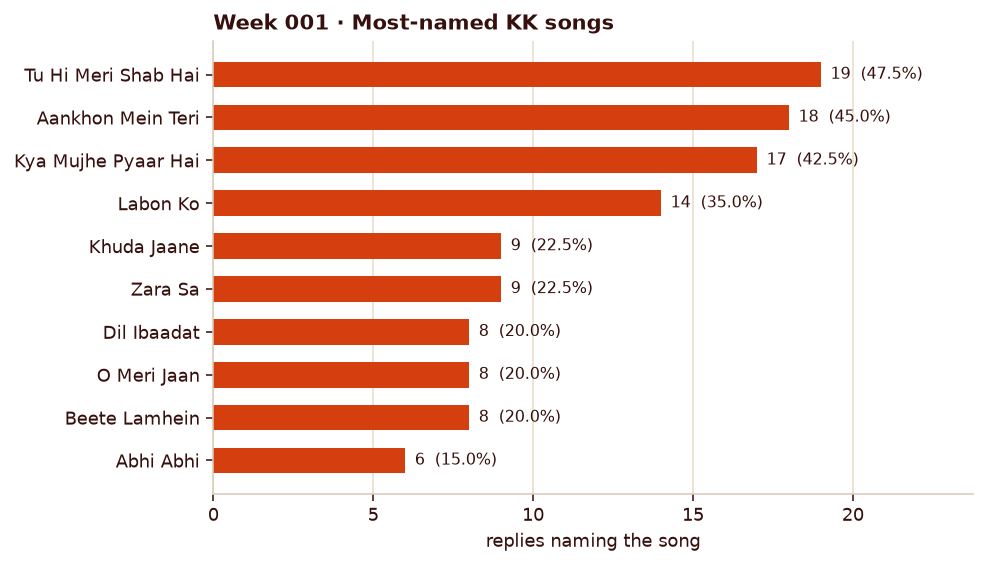

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.2))
bars = top10.sort_values("mentions")
ax.barh(bars["song"], bars["mentions"], color=VERMILION, height=0.6)
for y, (value, share) in enumerate(zip(bars["mentions"], bars["share_pct"])):
    ax.text(value + 0.3, y, f"{value}  ({share}%)", va="center", fontsize=8, color=INK)
ax.set_xlim(0, bars["mentions"].max() * 1.25)
ax.set_xlabel("replies naming the song")
ax.set_title("Week 001 · Most-named KK songs", loc="left", fontsize=11, weight="bold")
ax.grid(axis="x", color="#E8DCC8", linewidth=0.8)
ax.set_axisbelow(True)
fig.savefig(FIGURES / "week-001-top-songs.png")
plt.show()

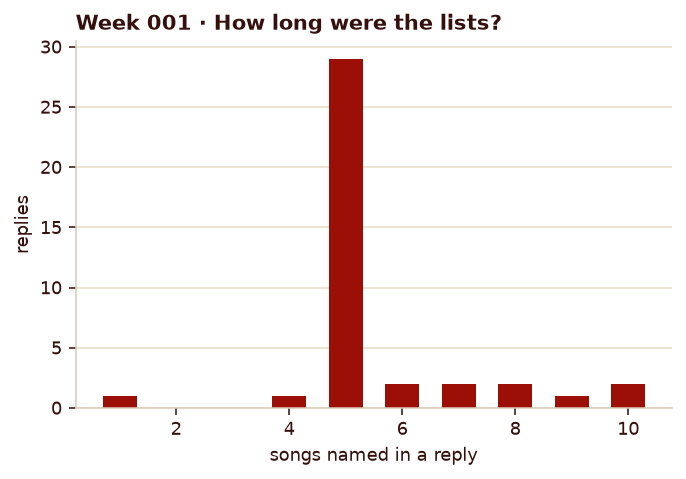

In [12]:
fig, ax = plt.subplots(figsize=(5.5, 3.4))
ax.bar(depth["songs_listed"], depth["replies"], color=CRIMSON, width=0.6)
ax.set_xlabel("songs named in a reply")
ax.set_ylabel("replies")
ax.set_title("Week 001 · How long were the lists?", loc="left", fontsize=11, weight="bold")
ax.grid(axis="y", color="#E8DCC8", linewidth=0.8)
ax.set_axisbelow(True)
fig.savefig(FIGURES / "week-001-list-length.png")
plt.show()

## 6 · Export

Two copies of every result table: one in `outputs/results/` (the notebook's own output, versioned
with the analysis) and one in the website's `public/data/week-01/`, which is what the charts read
at build time. Column names here are the ones the chart definitions refer to — keep them stable.

In [13]:
exports = {
    "top_songs.csv": top10[["song", "mentions", "share_pct", "score", "first_picks", "avg_rank"]],
    "all_songs.csv": songs,
    "first_choice.csv": top_first,
    "list_length.csv": depth,
    "votes_long.csv": long[["response_id", "rank", "song"]],
}

for name, frame in exports.items():
    frame.to_csv(RESULTS / name, index=False)
    if name != "all_songs.csv":          # the site only needs the small tables
        frame.to_csv(SITE_DATA / name, index=False)
    print(f"{name:<18} {len(frame):>4} rows")

print("\nresults →", RESULTS)
print("website →", SITE_DATA)

top_songs.csv        10 rows
all_songs.csv        64 rows
first_choice.csv      9 rows
list_length.csv       8 rows
votes_long.csv      221 rows

results → c:\Users\sarth\Documents\Projects\sarthaks-digital-playground\data-analysis\outputs\results
website → c:\Users\sarth\Documents\Projects\sarthaks-digital-playground\public\data\week-01


## 7 · Numbers for the week file

Paste these into `src/content/weeks/week-01.ts`, then flip `status` to `"published"`.

In [14]:
winner = top10.iloc[0]
summary = f"""
stats:
  Replies            {total_replies}
  Songs named        {len(long)} votes · {songs["song"].nunique()} distinct songs
  Most named         {winner["song"]} ({winner["mentions"]} replies, {winner["share_pct"]}%)
  Median list length {int(long.groupby("response_id").size().median())} songs
  One-vote wonders   {(songs["mentions"] == 1).sum()} songs named by exactly one person

charts (csv → columns):
  top_songs.csv     song, mentions, share_pct, score, first_picks, avg_rank
  first_choice.csv  song, first_picks
  list_length.csv   songs_listed, replies
"""
print(summary)


stats:
  Replies            40
  Songs named        221 votes · 64 distinct songs
  Most named         Tu Hi Meri Shab Hai (19 replies, 47.5%)
  Median list length 5 songs
  One-vote wonders   30 songs named by exactly one person

charts (csv → columns):
  top_songs.csv     song, mentions, share_pct, score, first_picks, avg_rank
  first_choice.csv  song, first_picks
  list_length.csv   songs_listed, replies

